 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...
 Converting Longitudinal Kinetics into VHT Behavioral Features...


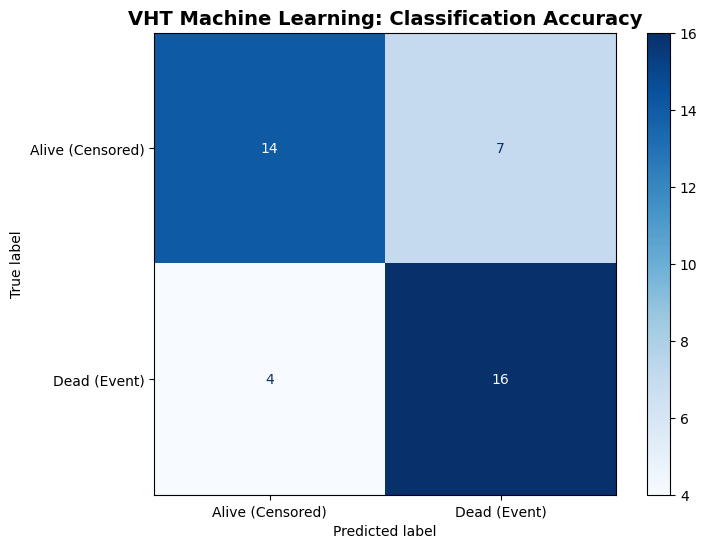

 VHT Matrix Complete: 39 components explain 95% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):


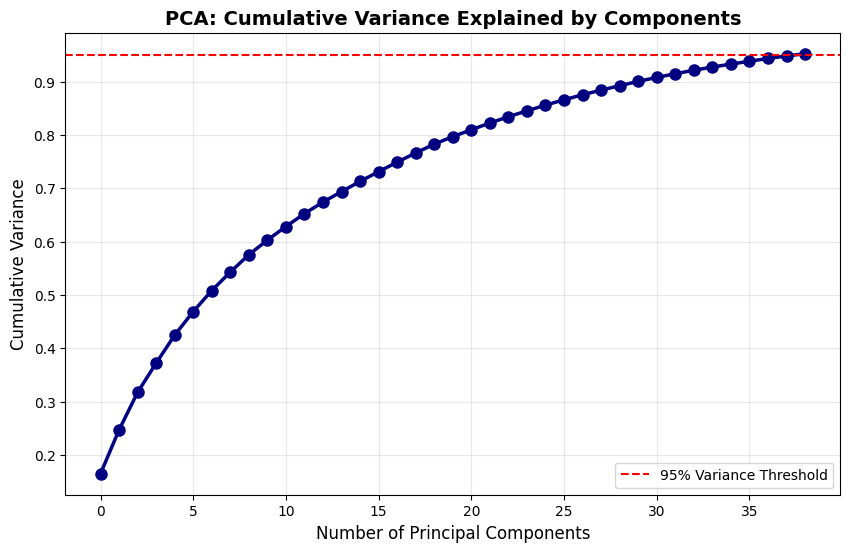

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_37893/1620540837.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(20).index, x=pc1_loadings.head(20).values, palette='viridis')


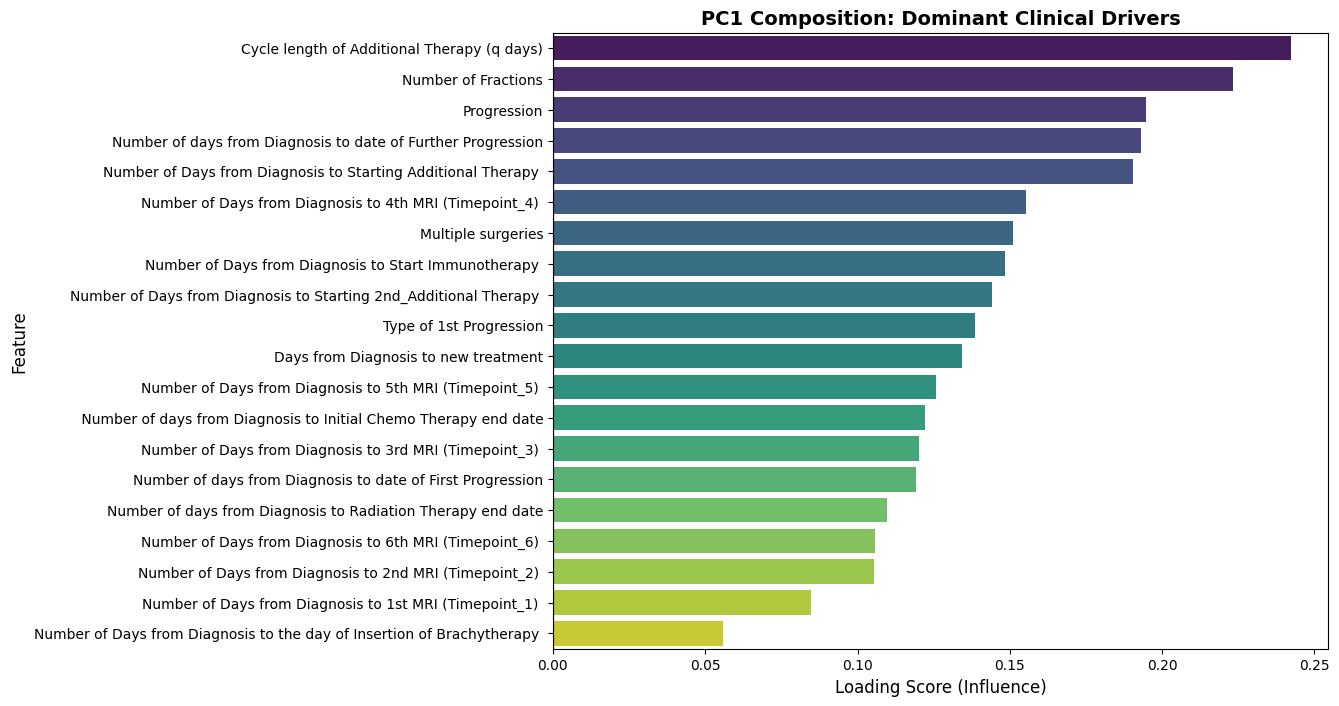

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -343.74
         time fit was run = 2026-05-10 17:52:59 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1       -0.21      0.81      0.03           -0.27           -0.14                0.76                0.87
PC2       -0.18      0.83      0.05           -0.29           -0.08                0.75                0.93
PC3       -0.05      0.95      0.05           -0.14            0.04                0.87                1.04
PC4        0.02      1.02      0.06           -0.10            0.13                0.91                1.14
PC5        0.02      1.02      0.06           -0.09            0.14                0.91                1.15
PC6        0.08      1.08      0.07           -0.05            0.21                0.95                1.23
PC7        0.02      1.03      0.07           -0.10            0.15                0.90                1.17
PC8        0.09      1.10      0.07           -0.04            0.23                0.96                1.25
PC9       -0.12      0.89      0.06           -0.24            0.01                0.79                1.01
PC10      -0.03      0.97      0.09           -0.21            0.16                0.81                1.17
PC11       0.03      1.03      0.09           -0.14            0.20                0.87                1.22
PC12      -0.03      0.97      0.10           -0.21            0.16                0.81                1.17
PC13       0.11      1.12      0.08           -0.05            0.27                0.95                1.31
PC14       0.02      1.02      0.10           -0.17            0.21                0.84                1.24
PC15       0.04      1.04      0.11           -0.17            0.25                0.84                1.28
PC16       0.04      1.05      0.09           -0.13            0.22                0.88                1.24
PC17      -0.24      0.78      0.10           -0.44           -0.05                0.65                0.95
PC18       0.05      1.06      0.10           -0.15            0.26                0.86                1.29
PC19      -0.06      0.94      0.11           -0.26            0.15                0.77                1.16
PC20       0.16      1.17      0.11           -0.06            0.38                0.94                1.47
PC21       0.06      1.07      0.12           -0.17            0.30                0.85                1.34
PC22      -0.00      1.00      0.13           -0.25            0.24                0.78                1.27
PC23       0.09      1.10      0.13           -0.16            0.35                0.85                1.42
PC24       0.21      1.23      0.13           -0.05            0.47                0.95                1.60
PC25      -0.30      0.74      0.13           -0.55           -0.04                0.58                0.96
PC26       0.11      1.12      0.15           -0.18            0.41                0.83                1.51
PC27      -0.09      0.91      0.16           -0.40            0.21                0.67                1.24
PC28      -0.17      0.84      0.16           -0.48            0.14                0.62                1.15
PC29       0.10      1.11      0.15           -0.19            0.39                0.83                1.47
PC30      -0.06      0.95      0.15           -0.35            0.23                0.71                1.26
PC31      -0.05      0.95      0.15           -0.33            0.24                0.72                1.27
PC32      -0

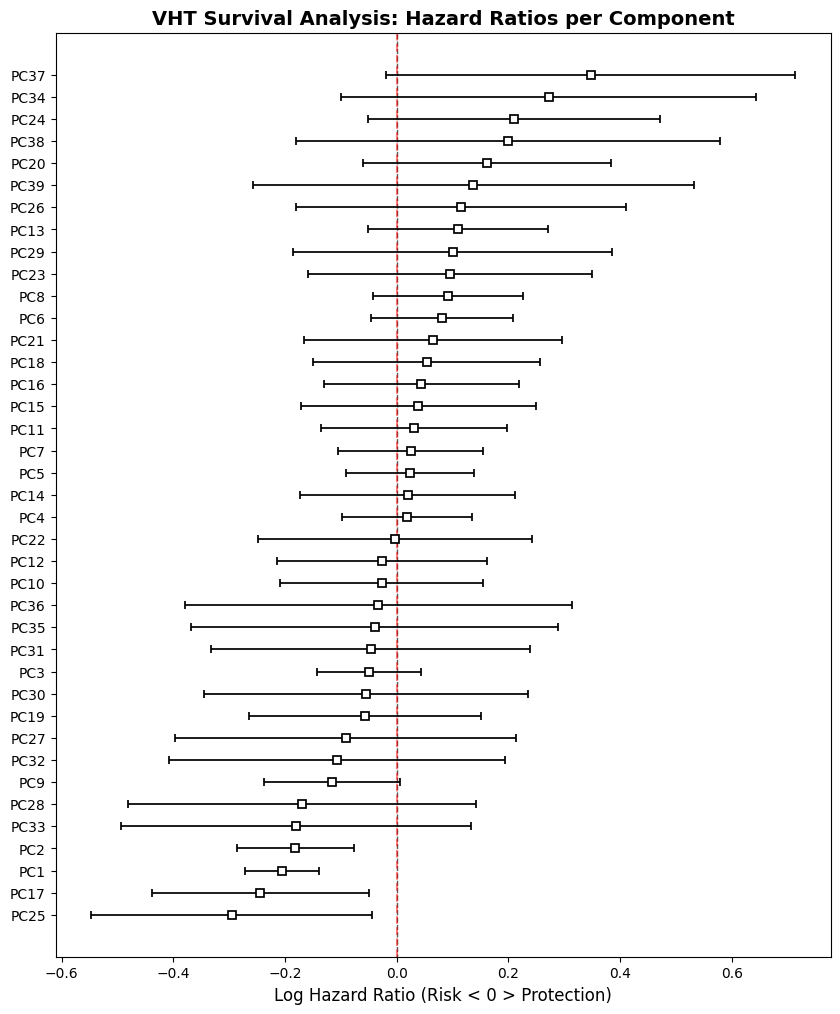

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION (Refined)
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            # Helper to pull the i-th scan in the sequence safely
            def get_val(key): 
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
    
    patient_objects[pid] = obj

# ======================================================================================
# 3. FEATURE ENGINEERING: TRANSFORM KINETICS INTO SCALARS
# ======================================================================================
print(" Converting Longitudinal Kinetics into VHT Behavioral Features...")
kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    history = None
    
    # Store rates for averaging
    rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    intensity_drifts = {f"Drift_{lbl}_{seq}": [] for lbl in label_map.values() for seq in ['t1c', 't2f']}

    for tp in sorted(obj['timepoints']):
        tp_num = "".join(filter(str.isdigit, tp))
        day = float(obj['clinical'].get(f"Timepoint_{tp_num}", np.nan))
        
        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            if dt > 0:
                for lbl in label_map.values():
                    # Growth Rate (mm3 / day)
                    v_rate = (obj['volumes'].get(tp, {}).get(lbl, 0) - history['vols'].get(lbl, 0)) / dt
                    rates[f"Vel_{lbl}"].append(v_rate)
                    # T1c Signal Drift (units / day)
                    t_rate = (obj['t1c_mean'].get(tp, {}).get(lbl, 0) - history['t1c'].get(lbl, 0)) / dt
                    intensity_drifts[f"Drift_{lbl}_t1c"].append(t_rate)
        
        history = {'day': day, 'vols': obj['volumes'].get(tp, {}), 't1c': obj['t1c_mean'].get(tp, {})}

    # Collapse longitudinal data into a single row per patient
    vht_row = {'PID_Clean': clean_id}
    for k, v in rates.items(): vht_row[k] = np.mean(v) if v else 0
    for k, v in intensity_drifts.items(): vht_row[k] = np.mean(v) if v else 0
    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features)

# ======================================================================================
# 4. MERGING & CLEANING FOR ML
# ======================================================================================
df_clinical = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
df_clinical['PID_Clean'] = df_clinical['Patient ID'].astype(str).str.split('-').str[0]

# Combine Baseline Clinical + Engineered Kinetic Rates
df_vht = pd.merge(df_clinical, df_kinetics, on='PID_Clean', how='inner')

# Identify targets and drop metadata
targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + ['Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)',
    'Type of Progression',             # Outcome variable
    'Type of 2nd Progression',         # Outcome variable
    'Second Progression/Recurrence'    # Outcome variable
]
X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns])

# Standard Preprocessing
for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Prepare y for the split to ensure we reference the actual data, not the name list
y_labels = df_vht[targets[0]].astype(int)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_smote, y_train_smote)

# We use y_test (actual values) instead of targets (list of names)
y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

# Plotting fix: disp.plot creates its own axis, we just need to set the title after
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()

# ======================================================================================
# 5. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=0.95) 
X_pca = pca.fit_transform(X_scaled)

print(f" VHT Matrix Complete: {X_pca.shape[1]} components explain 95% variance.")

# Show top drivers of PC1 (Now includes Velocities!)
pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
#print(pc1_drivers.head(10))

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(20).index, x=pc1_loadings.head(20).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# ======================================================================================
# 6. SURVIVAL MODELING (COX PCA)
# ======================================================================================
df_cox_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_cox_pca['duration'] = df_vht['Number of days from Diagnosis to death (Days)'].fillna(df_vht['Time to First Progression (Days)']).fillna(1).values
df_cox_pca['event'] = df_vht['Overall Survival (Death)'].astype(int).values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_pca[df_cox_pca['duration'] > 0], duration_col='duration', event_col='event')
cph.print_summary()

# D. COX HAZARD RATIO FOREST PLOT
plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()
